In [7]:
from frites.simulations import StimSpecAR
import matplotlib.pyplot as plt
from frites.config import CONFIG
from frites.conn import conn_dfc, define_windows, plot_windows
from frites.conn import (conn_covgc, conn_reshape_directed,
                         conn_reshape_undirected)
import numpy as np

## Prerequisites

To answer the questions of the exam, you need to run the initial part of the TD. So you must simulate a simple autoregressive model composed of a source signal X and a target signal Y (pairwise AR model). The source signal X is generated as a random walk with a Gaussian noise, and the target signal Y is generated as a linear combination of the source signal X and a Gaussian noise. 

Here, we use the class :class:`frites.simulations.StimSpecAR` to simulate an
stimulus-specific autoregressive model. For the pairwise models, you can
choose :

    * 'hga' : high-gamma burst
    * 'osc_40' / 'osc_20' : respectivelly 20hz and 40hz oscillations
    * 'ding_2' : pairwise Ding's model :cite:`ding2006granger`

In the current project, we choose the 'osc_40' model. 

In [8]:
# Here are the parameters of the simulation
ar_type = 'osc_40'  # 40hz oscillations
n_stim = 3          # number of stimulus
n_epochs = 100       # number of epochs per stimulus
n_times = 400
stim_onset = 100
dt = 100
sfreq = 200

ss = StimSpecAR()
ar = ss.fit(ar_type=ar_type, n_times=n_times, stim_onset=stim_onset, dt=dt, n_epochs=n_epochs, n_stim=n_stim, sf=sfreq, n_std=3)

40Hz oscillations AR model (n_times=400, n_epochs=100, n_stim=3, random_state=4076)


## 1) Single-trial time-resolved (dynamic) ranger causality (20 points)

Take the data simulated above and estimate dynamic functional connectivity between X and Y with the following parameters: window length = 0.2 seconds, win_step = 0.02  seconds. Use a lag = 0.01 seconds

a) Compute the Granger causality between X and Y, and plot the average Granger causality (10 points)

b) Test different window_length values and lags, and plot different examples, try to interpret the results (10 points)


In [10]:
slwin_len = .1    # 100ms window length
slwin_step = .02  # 20ms between consecutive windows
win_sample = define_windows(ar.times.data, slwin_len=slwin_len,
                            slwin_step=slwin_step)[0]

Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.1, start=-0.5, stop=1.495, step=0.02)


In [11]:
t0 = np.arange(0, 300, 4)
lag = 7
dt = 40
gc = conn_covgc(ar, dt, lag, t0, times=ar.times.data, roi=ar.roi.data)

# take the mean across trials
gc = gc.mean('trials')

Defining links (n_roi=2; directed=False; net=False, nb_min_links=None)
WARNING | The ratio between the lag and dt is 20.0%. It's recommended to conserve this ratio less than 10-15%. Try with a step=2
Compute the  covgc (method=gc, normalised=False, n_pairs=1; n_windows=75, lag=7, dt=40, step=1)


  0%|          |  : 0/1 [00:00<?,       ?it/s]

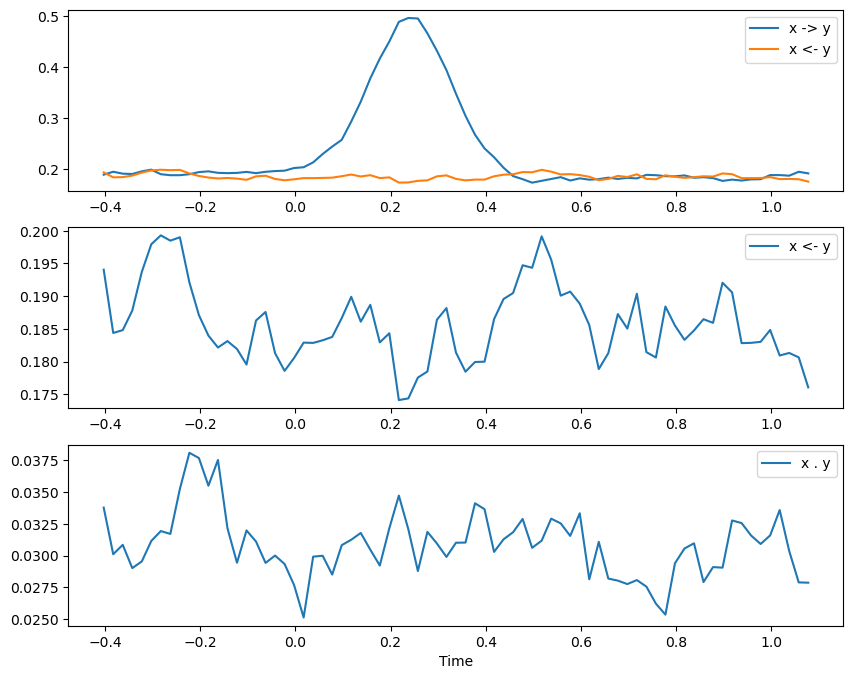

In [12]:
# Plotting the results
roi_p = gc['roi'].data

plt.figure(figsize=(10, 8))
plt.subplot(311)
for r in roi_p:
    plt.plot(gc.times.data, gc.sel(roi=r, direction='x->y').T,
             label=r.replace('-', ' -> '))
    plt.plot(gc.times.data, gc.sel(roi=r, direction='y->x').T,
             label=r.replace('-', ' <- '))

plt.legend()
plt.subplot(312)
for r in roi_p:
    plt.plot(gc.times.data, gc.sel(roi=r, direction='y->x').T,
             label=r.replace('-', ' <- '))
plt.legend()
plt.subplot(313)
for r in roi_p:
    plt.plot(gc.times.data, gc.sel(roi=r, direction='x.y').T,
             label=r.replace('-', ' . '))
plt.legend()
plt.xlabel('Time')
plt.show()

## 2) Across-trials Transfer Entropy (20 points)

e)	Simulate High-gamma activity (HGA) as in 1) and plot the single trials activities (7.5 points).

f)	Compute the transfer entropy between X and Y using a  max_delay=100 and plot the results (5 points)

g)	Test different window_length values and lags, and plot different examples, try to interpret the results (7.5 points)


In [88]:
ar_type = 'hga'  # High-gamma activity model
n_stim = 3          # number of stimulus
n_epochs = 100       # number of epochs per stimulus
n_times = 400
stim_onset = 100
dt = 100
sfreq = 200

ss = StimSpecAR()
ar = ss.fit(ar_type=ar_type, n_times=n_times, stim_onset=stim_onset, dt=dt, n_epochs=n_epochs, n_stim=n_stim, sf=sfreq, n_std=3)

Evoked HGA AR model (n_times=400, n_epochs=100, n_stim=3, random_state=3594)


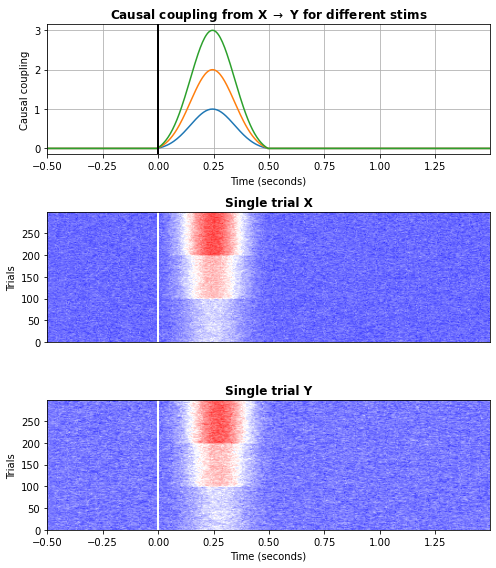

In [89]:
plt.figure(figsize=(7, 8))
ss.plot(cmap='bwr')
plt.tight_layout()
plt.show()

Evoked HGA AR model (n_times=300, n_epochs=500, n_stim=2, random_state=7019)
Defining links (n_roi=2; directed=True; net=False, nb_min_links=None)
Compute Transfer Entropy (n_pairs=2, delays=[1:1:50])


  0%|          | Estimating TE : 0/2 [00:00<?,       ?it/s]

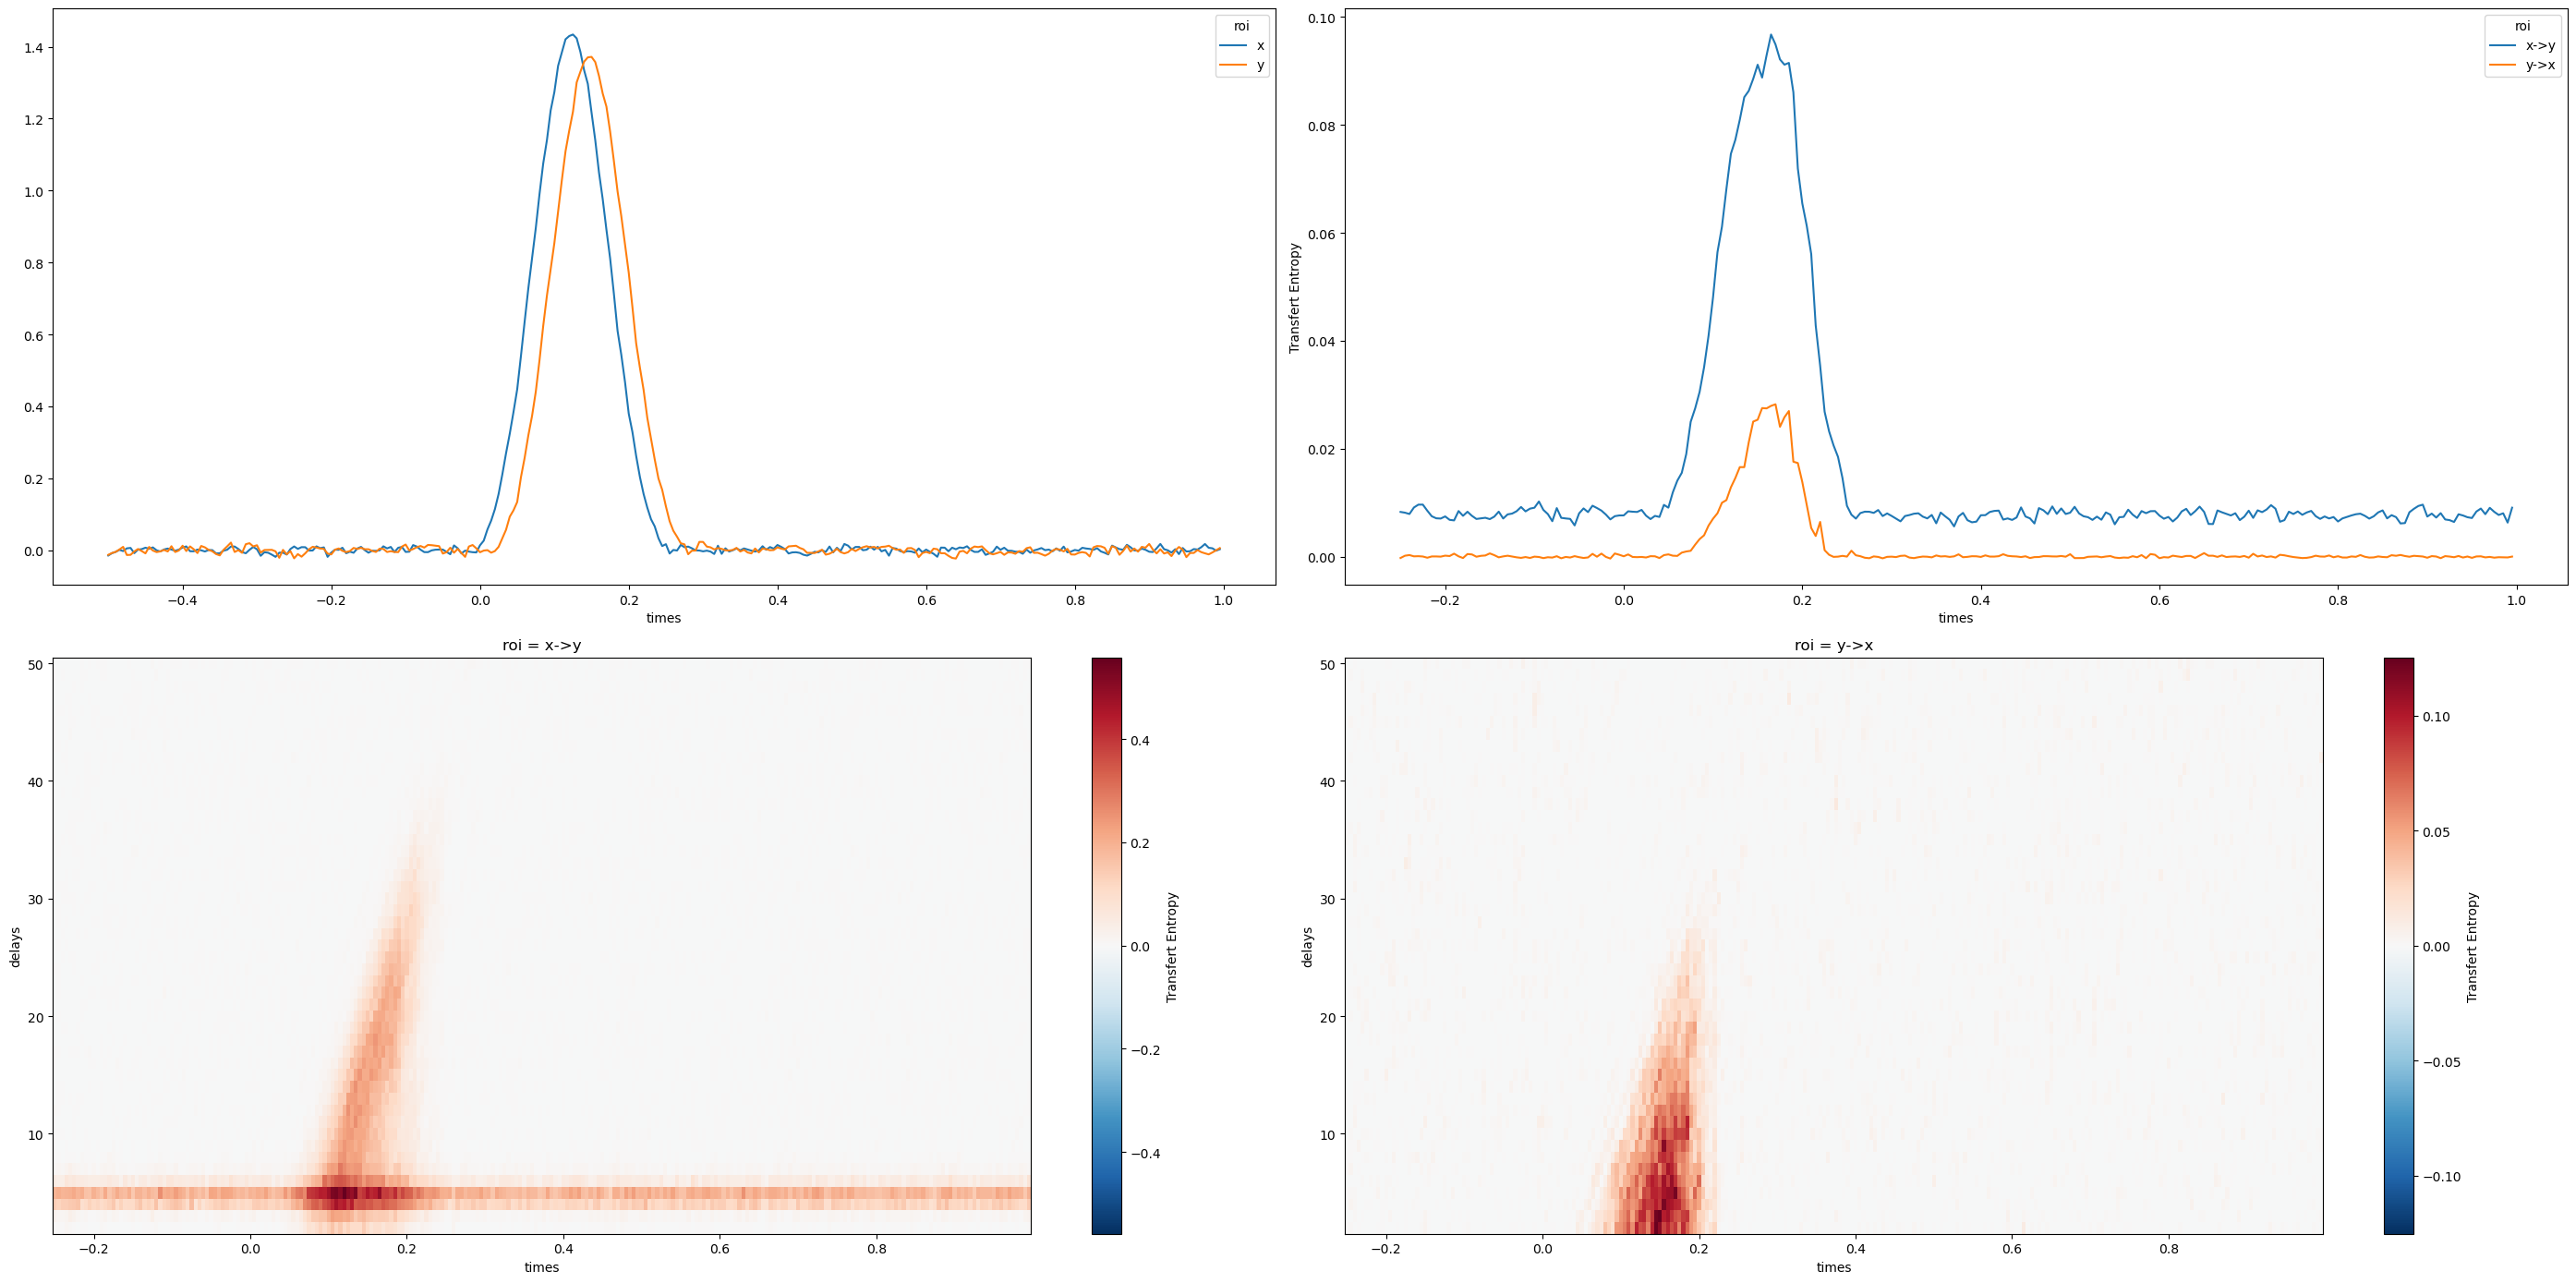

In [16]:
# Import connectivity estimation functions and transfer entropy
from frites.conn import conn_te

# Generate the data
ss = StimSpecAR()
ar = ss.fit(ar_type='hga', n_epochs=500, n_stim=2, n_std=3)

# Compute the transfer entropy
te = conn_te(ar, times='times', roi='roi', max_delay=50,
                return_delays=True, step_delay=1, min_delay=1)

# Plot the results
plt.figure(figsize=(28, 14))
plt.subplot(221)
ar.mean('trials').plot(x='times', hue='roi')
plt.subplot(222)
te.mean('delays').plot(x='times', hue='roi')
plt.subplot(223)
te.sel(roi='x->y').plot()
plt.subplot(224)
te.sel(roi='y->x').plot()
plt.tight_layout()
plt.show()